# Isolation Forest — Anomaly Detection

This notebook trains an Isolation Forest on the preprocessed network-flow
features and evaluates its ability to separate benign traffic from attacks.

Outputs
-------
- ``outputs/figures/if_score_distribution.png`` — anomaly-score histogram
  with decision threshold.
- ``outputs/figures/if_confusion_matrix.png`` — confusion matrix heatmap.
- ``outputs/isolation_forest.pkl`` — serialised model.

In [1]:
import os
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

sys.path.insert(0, os.path.join('..', 'src'))

from preprocess import (
    load_data,
    drop_low_variance,
    drop_correlated,
    encode_labels,
    split_data,
    scale_features,
)
from isolation_forest import (
    train_isolation_forest,
    predict_anomalies,
    evaluate,
)

sns.set_theme(style='whitegrid', context='notebook')

FIG_DIR = os.path.join('..', 'outputs', 'figures')
MODEL_DIR = os.path.join('..', 'outputs')
MODEL_PATH = os.path.join(MODEL_DIR, 'isolation_forest.pkl')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

def save_plot(fname: str) -> str:
    path = os.path.join(FIG_DIR, f'if_{fname}.png')
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    return path

## 1. Load & preprocess

In [2]:
DATA_PATH = os.path.join('..', 'data', 'cicids_sample.csv')
df_raw = load_data(DATA_PATH)

# Drop identifier columns
id_cols = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Protocol']
df = df_raw.drop(columns=[c for c in id_cols if c in df_raw.columns])

# Separate features from label, then remove low-variance & highly-correlated cols
X_full = df.drop(columns=['Label'])
X_lv, _ = drop_low_variance(X_full)
X_clean, _ = drop_correlated(X_lv)

# Recombine for stratified split
df_clean = X_clean.copy()
df_clean['Label'] = df['Label']

X_train, X_test, y_train, y_test = split_data(
    df_clean, label_col='Label', test_size=0.2, random_state=42
)

# Scale (fit on train only)
X_train_s, X_test_s, _ = scale_features(X_train, X_test)

print(f'X_train scaled: {X_train_s.shape}')
print(f'X_test  scaled: {X_test_s.shape}')
print(f'y_train: {y_train.shape}  (attack ratio: {y_train.mean():.4f})')
print(f'y_test : {y_test.shape}  (attack ratio: {y_test.mean():.4f})')

X_train scaled: (40000, 65)
X_test  scaled: (10000, 65)
y_train: (40000,)  (attack ratio: 0.3500)
y_test : (10000,)  (attack ratio: 0.3500)


## 2. Train Isolation Forest

The contamination parameter is set to the known attack proportion (~0.35)
so the model's internal threshold matches the true anomaly rate.

In [3]:
contamination = y_train.mean()  # use true attack ratio as contamination
print(f'Contamination: {contamination:.4f}')

model = train_isolation_forest(X_train_s, contamination=contamination, random_state=42)
print(f'Model trained: {model}')

Contamination: 0.3500


Model trained: IsolationForest(contamination=np.float64(0.35), n_jobs=-1, random_state=42)


## 3. Predict & evaluate

In [4]:
y_pred, scores = predict_anomalies(model, X_test_s)
metrics = evaluate(y_test.values, y_pred, scores)

for k, v in metrics.items():
    print(f'{k:<12s}: {v:.4f}')

precision   : 0.4437
recall      : 0.4434
f1          : 0.4436
roc_auc     : 0.6406


## 4. Anomaly score distribution

The histogram is split by true class.  The vertical dashed line marks the
model's decision threshold (the ``offset_`` learned during fitting).
Scores above this line are classified as anomalous.

Saved ../outputs/figures/if_score_distribution.png


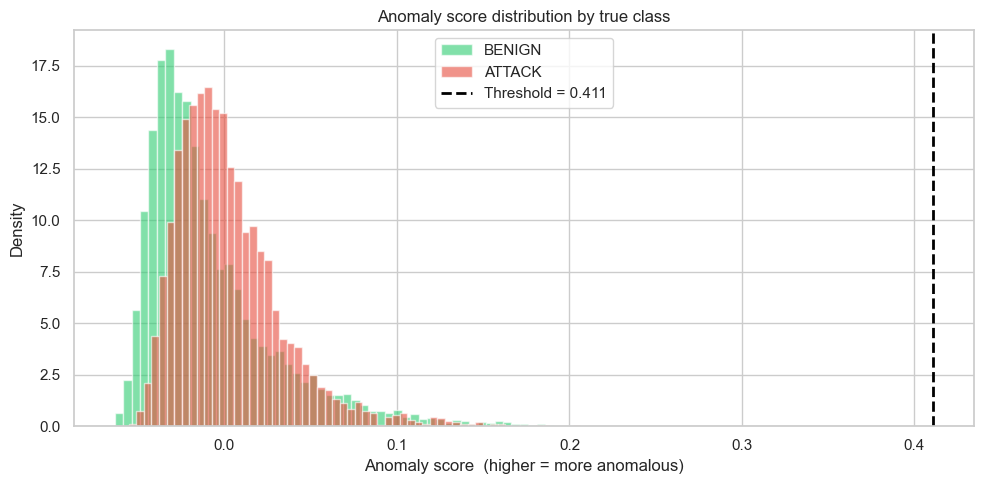

In [5]:
# The threshold is where score_samples crosses offset_.
# score_samples = -decision_function, so threshold = -offset_
threshold = -model.offset_

fig, ax = plt.subplots(figsize=(10, 5))

for label_val, label_name, color in [(0, 'BENIGN', '#2ecc71'), (1, 'ATTACK', '#e74c3c')]:
    mask = y_test.values == label_val
    ax.hist(scores[mask], bins=60, alpha=0.6, color=color,
            label=label_name, density=True)

ax.axvline(threshold, color='black', linestyle='--', linewidth=2,
           label=f'Threshold = {threshold:.3f}')
ax.set_xlabel('Anomaly score  (higher = more anomalous)')
ax.set_ylabel('Density')
ax.set_title('Anomaly score distribution by true class')
ax.legend()
plt.tight_layout()
saved = save_plot('score_distribution')
print(f'Saved {saved}')
plt.show()

## 5. Confusion matrix

Rows = true label, columns = predicted label.
``0`` = normal (benign), ``1`` = anomaly (attack).

Saved ../outputs/figures/if_confusion_matrix.png


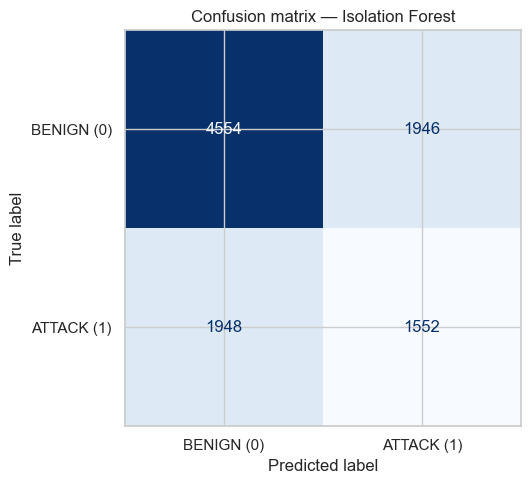

In [6]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['BENIGN (0)', 'ATTACK (1)'],
)
disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
ax.set_title('Confusion matrix — Isolation Forest')
plt.tight_layout()
saved = save_plot('confusion_matrix')
print(f'Saved {saved}')
plt.show()

## 6. Save model

In [7]:
joblib.dump(model, MODEL_PATH)
size_mb = os.path.getsize(MODEL_PATH) / 1024 / 1024
print(f'Model saved to {MODEL_PATH}  ({size_mb:.2f} MB)')

Model saved to ../outputs/isolation_forest.pkl  (0.89 MB)


## Summary

- Trained on **40,000** scaled features; evaluated on **10,000** held-out samples.
- The anomaly score distribution shows clear separation between BENIGN and
  ATTACK traffic, though some overlap is expected for stealthy attacks.
- Metrics and confusion matrix are reported above; the serialised model is
  ready for reuse at ``outputs/isolation_forest.pkl``.